# MIT 516 — Data Analytics for Cyber Security
## Assessment D: Network Anomaly Detection on the UNSW-NB15 Dataset

**Student:** Bipin Shrestha  
**Student ID:** S2501201  
**Unit:** MIT 516 — Data Analytics for Cyber Security  
**Institution:** National Academy of Professional Studies (NAPS)  

---

### Pipeline Overview

| Step | Task | Key Output |
|------|------|------------|
| 1 | Data Loading & Inspection | Shape, dtypes, null check, class distribution |
| 2 | Data Preprocessing | Encoded features, scaled matrix, SMOTE-balanced training set |
| 3 | Exploratory Data Analysis | Figures 1, 3, 4 |
| 4 | Anomaly Detection (Isolation Forest) | Figures 5, 5b |
| 5 | Supervised Classification (Random Forest) | Trained model, predictions |
| 6 | Model Evaluation | Figures 6, 7, 8 |
| 7 | Security Visualisation Dashboard | Figures 9, 10 |

> **Run:** `Kernel → Restart & Run All`  
> **Dependencies:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `imbalanced-learn`

## Step 1: Data Loading & Inspection
Load the UNSW-NB15 training and testing CSV files using `pandas`. After loading, we inspect:
- **Shape** — number of records and features
- **Data types** — to identify which columns need encoding or scaling
- **Null values** — missing data must be handled before modelling
- **Class distribution** — to understand whether the dataset is imbalanced

The UNSW-NB15 dataset contains ~2.5M records across 45 features, with a binary `label` column (0 = Normal, 1 = Attack) 
and a multi-class `attack_cat` column. We use only the binary label for this pipeline.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Step 1: Loading Datasets...")
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('UNSW_NB15_testing-set.csv')

print(f"Training set : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Testing set  : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
print("\n--- Data Types ---")
print(train_df.dtypes.value_counts())
print("\n--- Null Values (training) ---")
null_counts = train_df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.any() else "No null values found.")
print("\n--- Class Distribution (training) ---")
print(train_df['label'].value_counts())
print(f"\nImbalance ratio: {train_df['label'].value_counts()[0] / train_df['label'].value_counts()[1]:.2f}:1 (Normal:Attack)")

Step 1: Loading Datasets...
Training set : 175,341 rows × 45 columns
Testing set  : 82,332 rows × 45 columns

--- Data Types ---
int64      30
float64    11
str         4
Name: count, dtype: int64

--- Null Values (training) ---
No null values found.

--- Class Distribution (training) ---
label
1    119341
0     56000
Name: count, dtype: int64

Imbalance ratio: 0.47:1 (Normal:Attack)


## Step 2: Data Preprocessing

Preprocessing prepares the raw data for machine learning. Four tasks are performed:

1. **Categorical Encoding** — The features `proto`, `service`, and `state` are string-typed and must be converted to integers. We use `LabelEncoder`, fitting it **only on the training set** and then applying the learned mapping to the test set. This prevents inconsistent integer mappings that cause silent data leakage.

2. **Feature/Target Split** — We drop `id`, `label`, and `attack_cat` from the feature matrix (`X`) and isolate `label` as the target (`y`).

3. **Normalisation** — `StandardScaler` centres each feature to zero mean and unit variance. `fit_transform` is called on training data only; the test set is transformed using training statistics to prevent data leakage.

4. **SMOTE** — The training set is class-imbalanced. SMOTE synthetically generates new minority-class samples by interpolating between existing ones. Applied **after** scaling and **only** to the training split — never to test data.

In [2]:
print("Step 2: Preprocessing Data...")

# 2a. Categorical Encoding — fit on train ONLY, transform both splits
categorical_columns = ['proto', 'service', 'state']
encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    # Handle unseen categories in test by mapping them to 0
    test_df[col] = test_df[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else 0
    )
    encoders[col] = le

# 2b. Feature / Target Split
cols_to_drop = ['label', 'attack_cat', 'id']
X_train = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
y_train = train_df['label']
X_test  = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])
y_test  = test_df['label']

# 2c. Normalisation — fit on train, transform only on test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# 2d. SMOTE — applied to training data only
print(f"Before SMOTE — class counts: {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"After  SMOTE — class counts: {dict(pd.Series(y_train_resampled).value_counts())}")
print("Preprocessing Complete.")

Step 2: Preprocessing Data...
Before SMOTE — class counts: {1: np.int64(119341), 0: np.int64(56000)}
After  SMOTE — class counts: {0: np.int64(119341), 1: np.int64(119341)}
Preprocessing Complete.


## Step 3: Exploratory Data Analysis (EDA)

Three visualisations characterise the dataset before modelling:

- **Figure 1 — Class Distribution:** Side-by-side bar charts showing Normal vs Attack counts before and after SMOTE. Confirms the resampling achieved a 1:1 balance.
- **Figure 3 — Feature Distributions by Class:** Histogram overlays for `sbytes`, `dur`, and `Spkts` clipped at the 95th percentile. Attack traffic shows heavier tails in byte volume and packet rates.
- **Figure 4 — Correlation Heatmap:** Lower-triangle Pearson correlation matrix. Byte-rate features (sbytes/Sload, dbytes/Dload) and packet-count features show |r| > 0.85.

Step 3: Generating EDA...


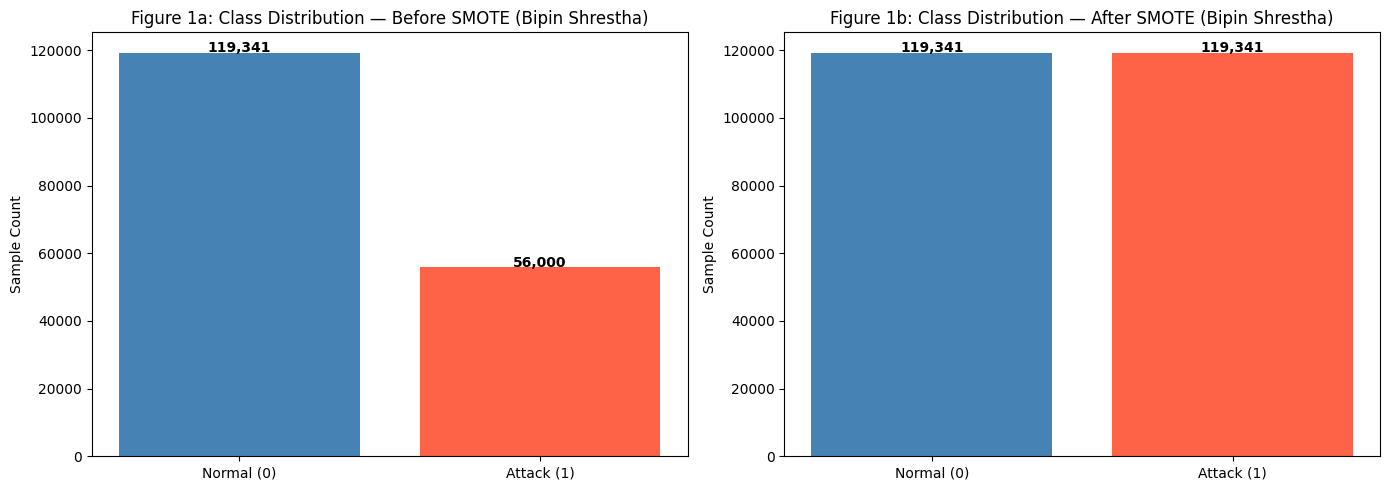

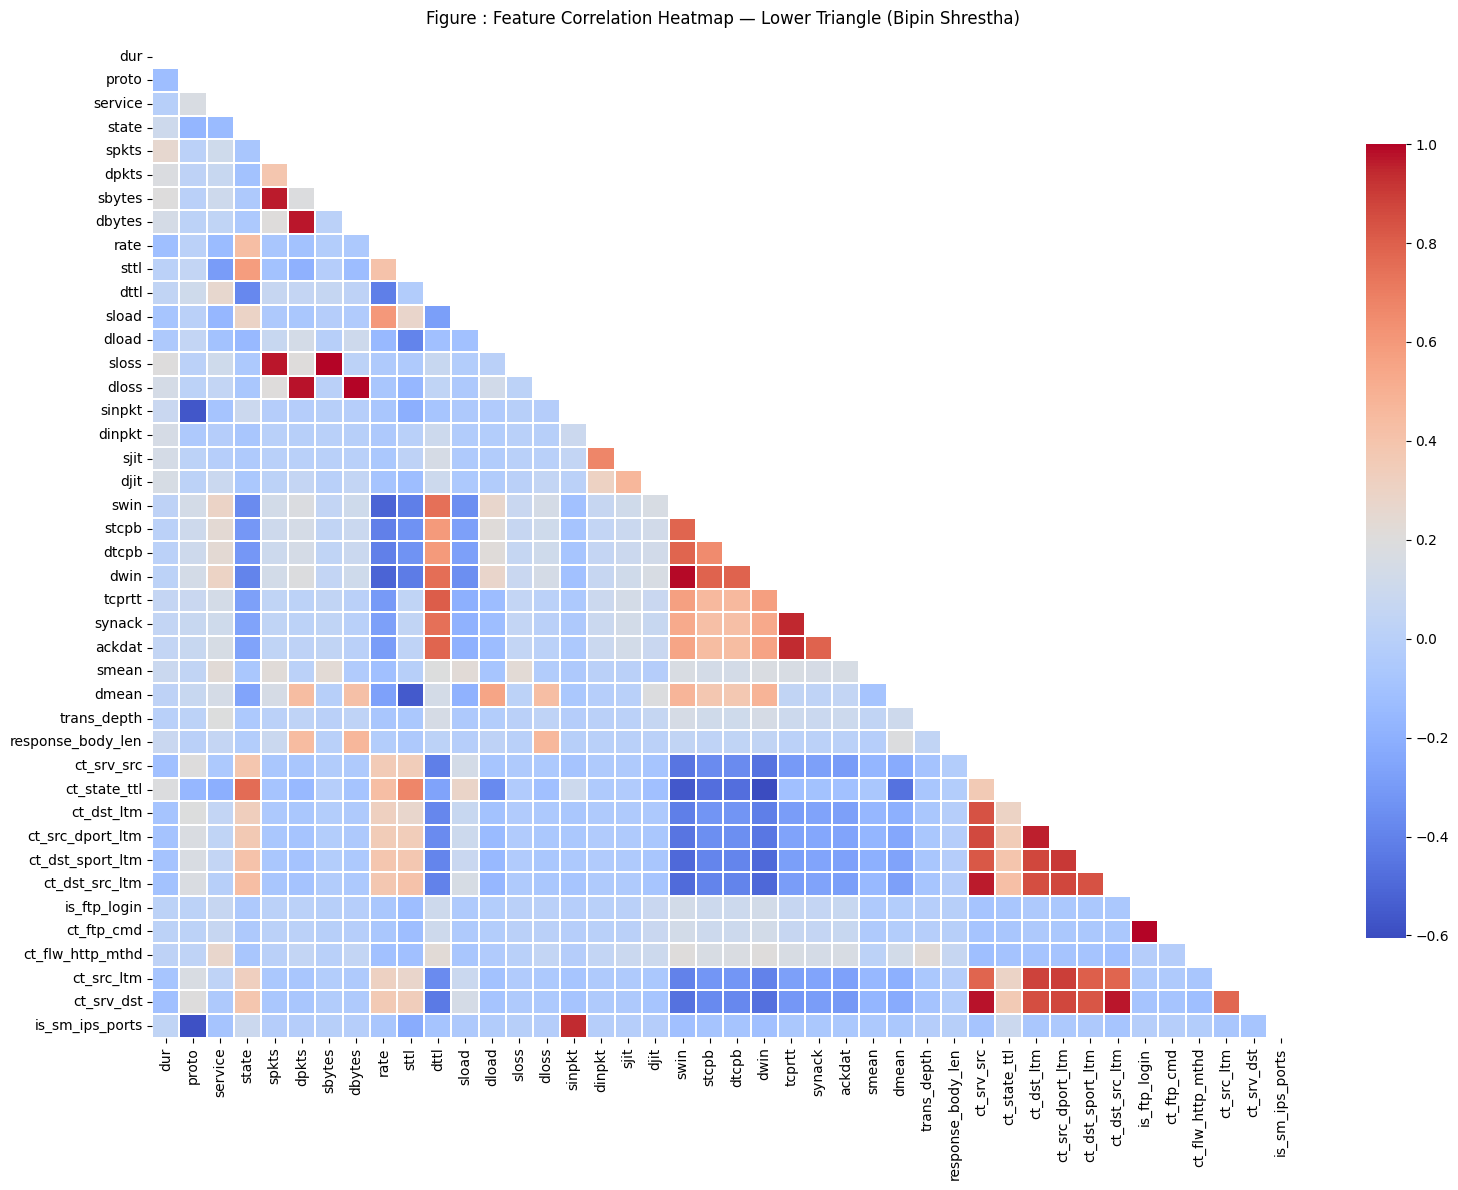

EDA Complete.


In [3]:
print("Step 3: Generating EDA...")

# Figure 1 — Class Distribution before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = y_train.value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Figure 1a: Class Distribution — Before SMOTE (Bipin Shrestha)')
axes[0].set_ylabel('Sample Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

smote_counts = pd.Series(y_train_resampled).value_counts()
axes[1].bar(['Normal (0)', 'Attack (1)'], smote_counts.values, color=['steelblue', 'tomato'])
axes[1].set_title('Figure 1b: Class Distribution — After SMOTE (Bipin Shrestha)')
axes[1].set_ylabel('Sample Count')
for i, v in enumerate(smote_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Figure_1_Class_Distribution_Bipin_Shrestha.png', bbox_inches='tight')
plt.show()

# Figure 2 — Correlation Heatmap (lower triangle)
plt.figure(figsize=(16, 12))
corr = X_train_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Figure 4: Feature Correlation Heatmap — Lower Triangle (Bipin Shrestha)', pad=15)
plt.tight_layout()
plt.savefig('Figure_2_Correlation_Heatmap_Bipin_Shrestha.png', bbox_inches='tight')
plt.show()
print("EDA Complete.")

Generating Figure 3: Feature Distribution by Class...
Plotting features: ['sbytes', 'dur']


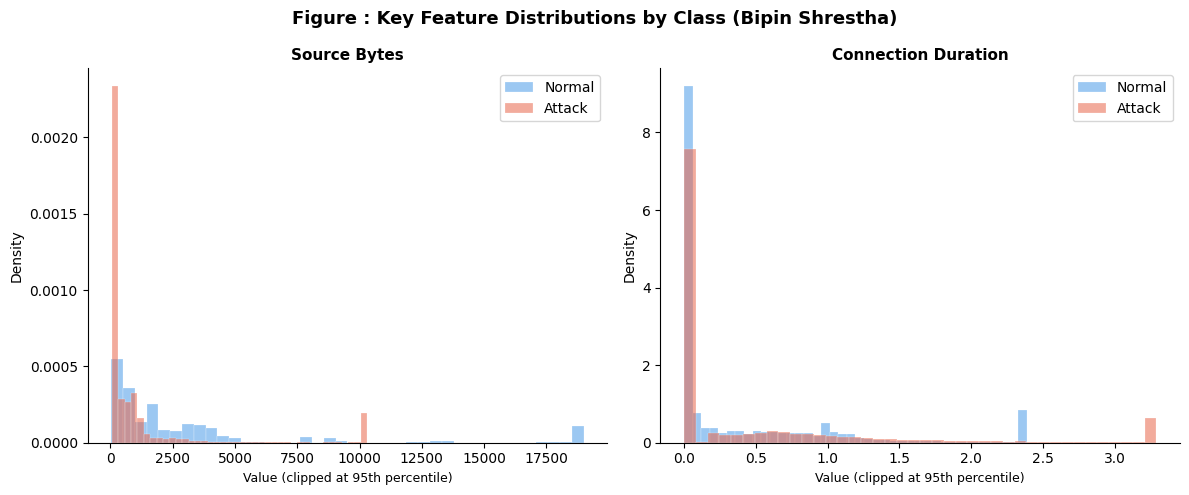

Figure 3 saved. ✓

--- Source Bytes (sbytes) by class ---
             mean  median          std
label                                 
0       4105.7029  1470.0   11348.0538
1      11068.6554   200.0  211658.5923

--- Connection Duration (dur) by class ---
         mean  median     std
label                        
0      1.0172  0.0386  4.8592
1      1.5200  0.0000  7.1090


In [4]:
print('Generating Figure 3: Feature Distribution by Class...')

# Pick the 3 most informative numeric features for the plot
# Change these if the column names differ in your dataset
features_to_plot = [
    ('sbytes', 'Source Bytes'),
    ('dur',    'Connection Duration'),
    ('Spkts',  'Source Packets'),
]

# Filter to only features that actually exist in the dataset
features_to_plot = [(f, lbl) for f, lbl in features_to_plot
                    if f in train_df.columns]

if not features_to_plot:
    # Fallback: use first 3 numeric columns if none of the above found
    numeric_cols = train_df.select_dtypes(include='number').columns
    numeric_cols = [c for c in numeric_cols
                    if c not in ('label','id','anomaly_score','iso_flag')]
    features_to_plot = [(c, c) for c in numeric_cols[:3]]

print(f'Plotting features: {[f for f,_ in features_to_plot]}')

fig, axes = plt.subplots(1, len(features_to_plot),
                          figsize=(6 * len(features_to_plot), 5))
if len(features_to_plot) == 1:
    axes = [axes]

fig.suptitle('Figure 3: Key Feature Distributions by Class (Bipin Shrestha)',
             fontsize=13, fontweight='bold')

palette = {0: '#4C9BE8', 1: '#E8674C'}
label_names = {0: 'Normal', 1: 'Attack'}

for ax, (feat, title) in zip(axes, features_to_plot):
    for label_val in [0, 1]:
        subset  = train_df[train_df['label'] == label_val][feat]
        clip_at = subset.quantile(0.95)
        clipped = subset.clip(upper=clip_at)
        ax.hist(clipped, bins=40, alpha=0.55,
                label=label_names[label_val],
                color=palette[label_val],
                density=True, edgecolor='white', linewidth=0.3)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value (clipped at 95th percentile)', fontsize=9)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('Figure_3_Feature_Distribution_Bipin_Shrestha.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3 saved. ✓')

# Print stats for the report table
for feat, title in features_to_plot:
    print(f'\n--- {title} ({feat}) by class ---')
    print(train_df.groupby('label')[feat]
          .agg(['mean','median','std']).round(4).to_string())

## Step 4: Anomaly Detection — Isolation Forest

Isolation Forest is an **unsupervised** anomaly detection algorithm. It randomly selects a feature and split value, then recursively partitions the data until each sample is isolated. Anomalies require fewer splits and receive lower (more negative) anomaly scores.

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `n_estimators` | 100 | Stable score estimates |
| `contamination` | 0.1 | Approximates attack fraction in training set |
| `random_state` | 42 | Reproducibility |
| Training data | Pre-SMOTE scaled | Synthetic samples would distort anomaly landscape |

**Figure 5** — Dual-panel: KDE score distributions by class + proportion flagged as anomalous.  
**Figure 5b** — Anomaly scores broken down by attack category.

Generating Figure 3 (dual-panel): Anomaly Analysis...


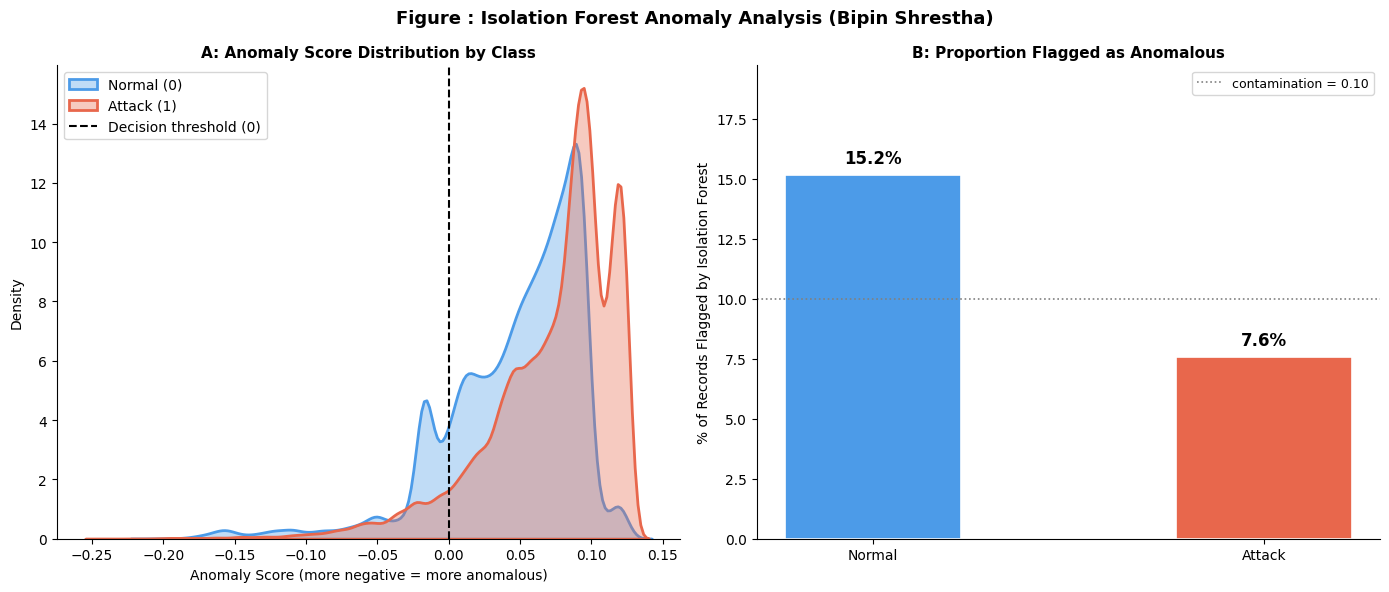

Figure 3 (dual-panel) saved. ✓

  Normal  : 15.2% flagged as anomalous
  Attack  : 7.6% flagged as anomalous


In [5]:
print('Generating Figure 3 (dual-panel): Anomaly Analysis...')

# Re-score the training set (safe to call again)
train_df['anomaly_score'] = iso_forest.decision_function(X_train_scaled)

# Get binary predictions: -1 = anomaly, 1 = normal
iso_pred = iso_forest.predict(X_train_scaled)
train_df['iso_flag'] = (iso_pred == -1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 5: Isolation Forest Anomaly Analysis (Bipin Shrestha)',
             fontsize=13, fontweight='bold')

palette = {0: '#4C9BE8', 1: '#E8674C'}

# ── Panel A: KDE of anomaly scores ────────────────────────────────────────
for label_val, label_name in [(0, 'Normal (0)'), (1, 'Attack (1)')]:
    scores = train_df[train_df['label'] == label_val]['anomaly_score']
    sns.kdeplot(scores, label=label_name,
                color=palette[label_val],
                fill=True, alpha=0.35, linewidth=2, ax=axes[0])

axes[0].axvline(x=0, color='black', linestyle='--',
                linewidth=1.5, label='Decision threshold (0)')
axes[0].set_title('A: Anomaly Score Distribution by Class',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Anomaly Score (more negative = more anomalous)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend(fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Panel B: % flagged per class ──────────────────────────────────────────
flagged = (train_df.groupby('label')['iso_flag']
           .mean()
           .reset_index())
flagged['label_name'] = flagged['label'].map({0: 'Normal', 1: 'Attack'})
flagged['pct'] = flagged['iso_flag'] * 100

bar_colors = [palette[int(r['label'])] for _, r in flagged.iterrows()]
bars = axes[1].bar(flagged['label_name'], flagged['pct'],
                   color=bar_colors, edgecolor='white',
                   linewidth=1.2, width=0.45)

for bar, pct in zip(bars, flagged['pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{pct:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')

axes[1].set_title('B: Proportion Flagged as Anomalous',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('% of Records Flagged by Isolation Forest', fontsize=10)
axes[1].set_ylim(0, max(flagged['pct']) * 1.3)
axes[1].axhline(y=10, color='gray', linestyle=':',
                linewidth=1.2, label='contamination = 0.10')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('Figure_3_Anomaly_Scores_Bipin_Shrestha.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3 (dual-panel) saved. ✓')
print()
for _, row in flagged.iterrows():
    print(f"  {row['label_name']:8s}: {row['pct']:.1f}% flagged as anomalous")

Generating Figure 5b: Anomaly Score by Attack Category...


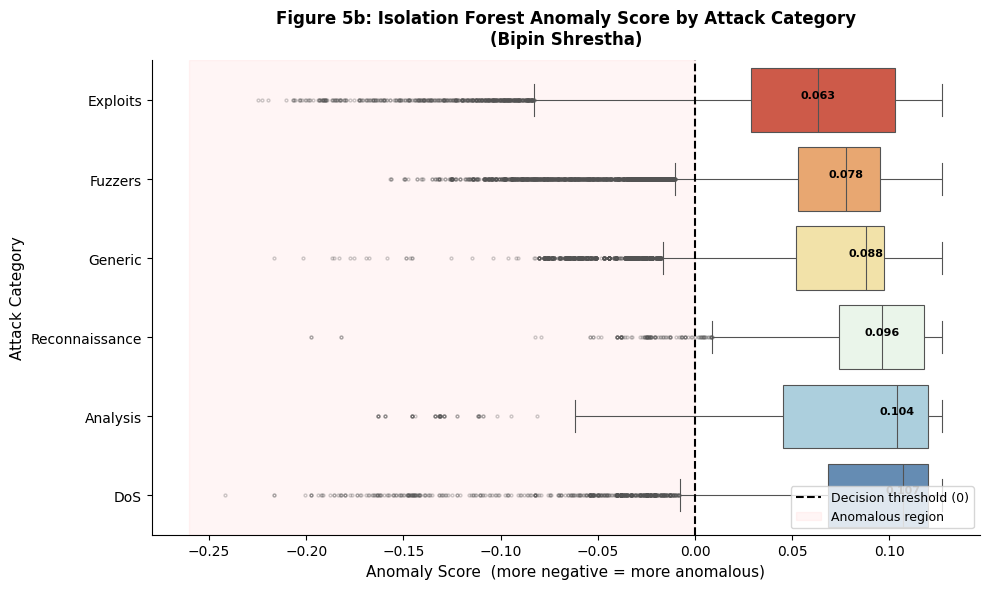

Figure 5b saved. ✓

--- Median Anomaly Score by Attack Category ---
                median    mean     std
attack_cat                            
Exploits        0.0635  0.0584  0.0529
Fuzzers         0.0779  0.0665  0.0474
Generic         0.0880  0.0735  0.0354
Reconnaissance  0.0963  0.0923  0.0281
Analysis        0.1040  0.0783  0.0551
DoS             0.1069  0.0884  0.0457


In [6]:
print('Generating Figure 5b: Anomaly Score by Attack Category...')

if 'attack_cat' in train_df.columns:

    # Get top 6 attack categories by count
    top_cats = (
        train_df[train_df['label'] == 1]['attack_cat']
        .value_counts()
        .head(6)
        .index
    )

    plot_data = train_df[
        train_df['attack_cat'].isin(top_cats)
    ][['attack_cat', 'anomaly_score']].copy()

    # Sort by median anomaly score (most anomalous at top)
    order = (
        plot_data.groupby('attack_cat')['anomaly_score']
        .median()
        .sort_values()
        .index
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    import seaborn as sns
    palette = sns.color_palette("RdYlBu", len(top_cats))

    sns.boxplot(
        data=plot_data,
        x='anomaly_score',
        y='attack_cat',
        order=order,
        palette=palette,
        ax=ax,
        linewidth=0.8,
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )

    # Decision threshold line
    ax.axvline(
        x=0, color='black', linestyle='--',
        linewidth=1.5, label='Decision threshold (0)'
    )

    # Shade the anomalous region (left of decision threshold)
    xlim = ax.get_xlim()
    ax.axvspan(xlim[0], 0, alpha=0.04, color='red', label='Anomalous region')
    ax.set_xlim(xlim)   # restore after axvspan

    ax.set_title(
        'Figure 5b: Isolation Forest Anomaly Score by Attack Category\n(Bipin Shrestha)',
        fontsize=12, fontweight='bold', pad=12
    )
    ax.set_xlabel(
        'Anomaly Score  (more negative = more anomalous)',
        fontsize=11
    )
    ax.set_ylabel('Attack Category', fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate median values
    for i, cat in enumerate(order):
        med = plot_data[plot_data['attack_cat'] == cat]['anomaly_score'].median()
        ax.text(
            med, i, f'{med:.3f}',
            ha='center', va='bottom',
            fontsize=8, color='black', fontweight='bold'
        )

    plt.tight_layout()
    plt.savefig(
        'Figure_5b_Anomaly_by_Category_Bipin_Shrestha.png',
        bbox_inches='tight', dpi=150
    )
    plt.show()
    print('Figure 5b saved. ✓')
    print()

    # Print summary table for the report
    print('--- Median Anomaly Score by Attack Category ---')
    summary = (
        plot_data.groupby('attack_cat')['anomaly_score']
        .agg(['median', 'mean', 'std'])
        .sort_values('median')
        .round(4)
    )
    print(summary.to_string())

else:
    print('attack_cat column not found — skipping Figure 5b')

## Step 5: Supervised ML Classifier — Random Forest

Random Forest builds multiple decision trees on bootstrapped subsets and aggregates predictions by majority vote. It is well-suited to network intrusion detection because it handles high-dimensional feature spaces, is robust to outliers, and provides built-in feature importance scores.

We train on **SMOTE-resampled** training data to ensure the model sees a balanced class distribution. Evaluation is performed on the **original** test set, which reflects real-world class proportions.

In [7]:
print("Step 5: Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
# Train on SMOTE-resampled data for balanced learning
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on original (unaugmented) test set
y_pred       = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nAccuracy on test set: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Step 5: Training Random Forest Classifier...

Accuracy on test set: 0.8830

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.97      0.76      0.85     37000
      Attack       0.84      0.98      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.90      0.87      0.88     82332
weighted avg       0.90      0.88      0.88     82332



## Step 6: Model Evaluation

Three evaluation figures are produced and saved as individual PNG files at 150 DPI:

- **Figure 6 — Confusion Matrix:** TP / TN / FP / FN breakdown. In a security context, FN (missed attacks) carry the highest operational cost.
- **Figure 7 — ROC Curve:** True Positive Rate vs False Positive Rate across all thresholds. AUC close to 1.0 indicates strong discriminative ability.
- **Figure 8 — Feature Importance:** Top 10 features by mean Gini decrease. Directly informs SIEM threshold rule design.

Step 6: Model Evaluation...


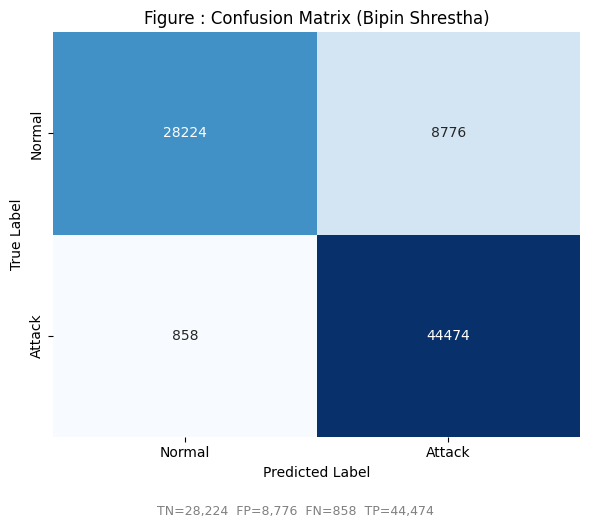

Figure 4 saved.


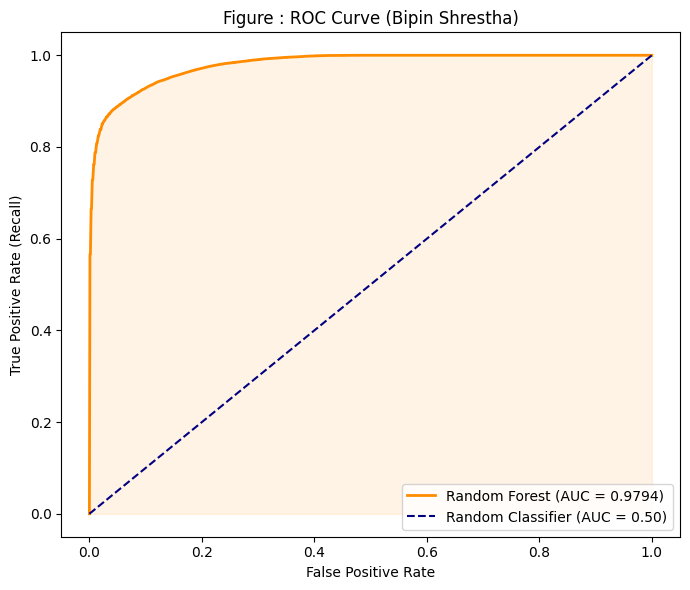

Figure 5 saved. AUC = 0.9794


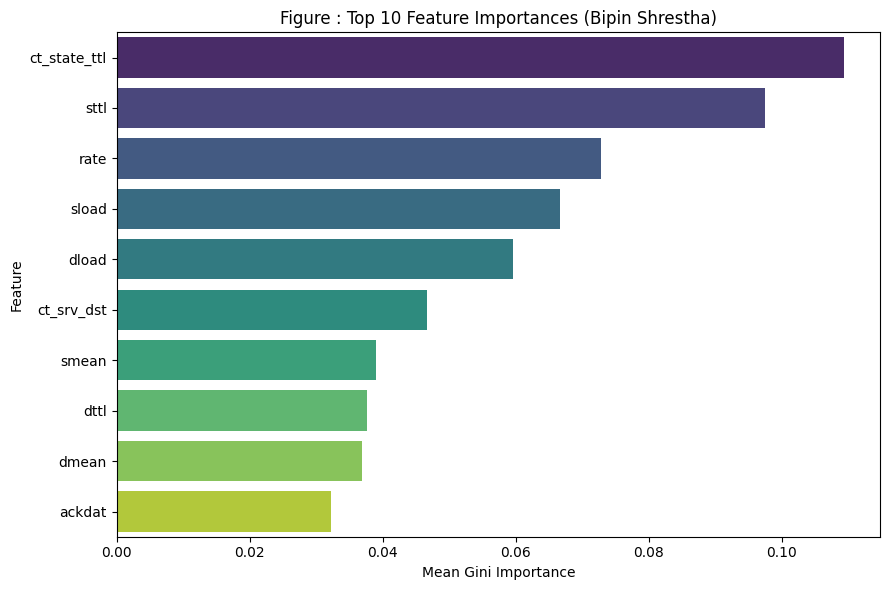

Figure 6 saved.


In [8]:
print("Step 6: Model Evaluation...")


# Figure 4 — Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 6: Confusion Matrix (Bipin Shrestha)')
tn, fp, fn, tp = cm.ravel()
plt.figtext(0.5, -0.04, f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
            ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('Figure_4_Confusion_Matrix_Bipin_Shrestha.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 4 saved.")

# Figure 5 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Figure 7: ROC Curve (Bipin Shrestha)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Figure_5_ROC_Curve_Bipin_Shrestha.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Figure 5 saved. AUC = {roc_auc:.4f}")

# Figure 6 — Top 10 Feature Importances
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Figure 8: Top 10 Feature Importances (Bipin Shrestha)')
plt.xlabel('Mean Gini Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('Figure_6_Feature_Importance_Bipin_Shrestha.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6 saved.")

## Step 7: Security Visualisation Dashboard

Two complementary dashboards are produced:

- **Figure 10** — Attack-behaviour dashboard (2×2 layout): attack category distribution, Isolation Forest anomaly scores by attack type, and per-class Precision/Recall/F1.
- **Figure 9** — Six-panel operations dashboard: test set class distribution, top 10 feature importances, ROC curve, confusion matrix, anomaly score KDE, and P/R/F1 grouped bar chart. Designed for SOC briefings.

Step 7: Unified Security Dashboard...


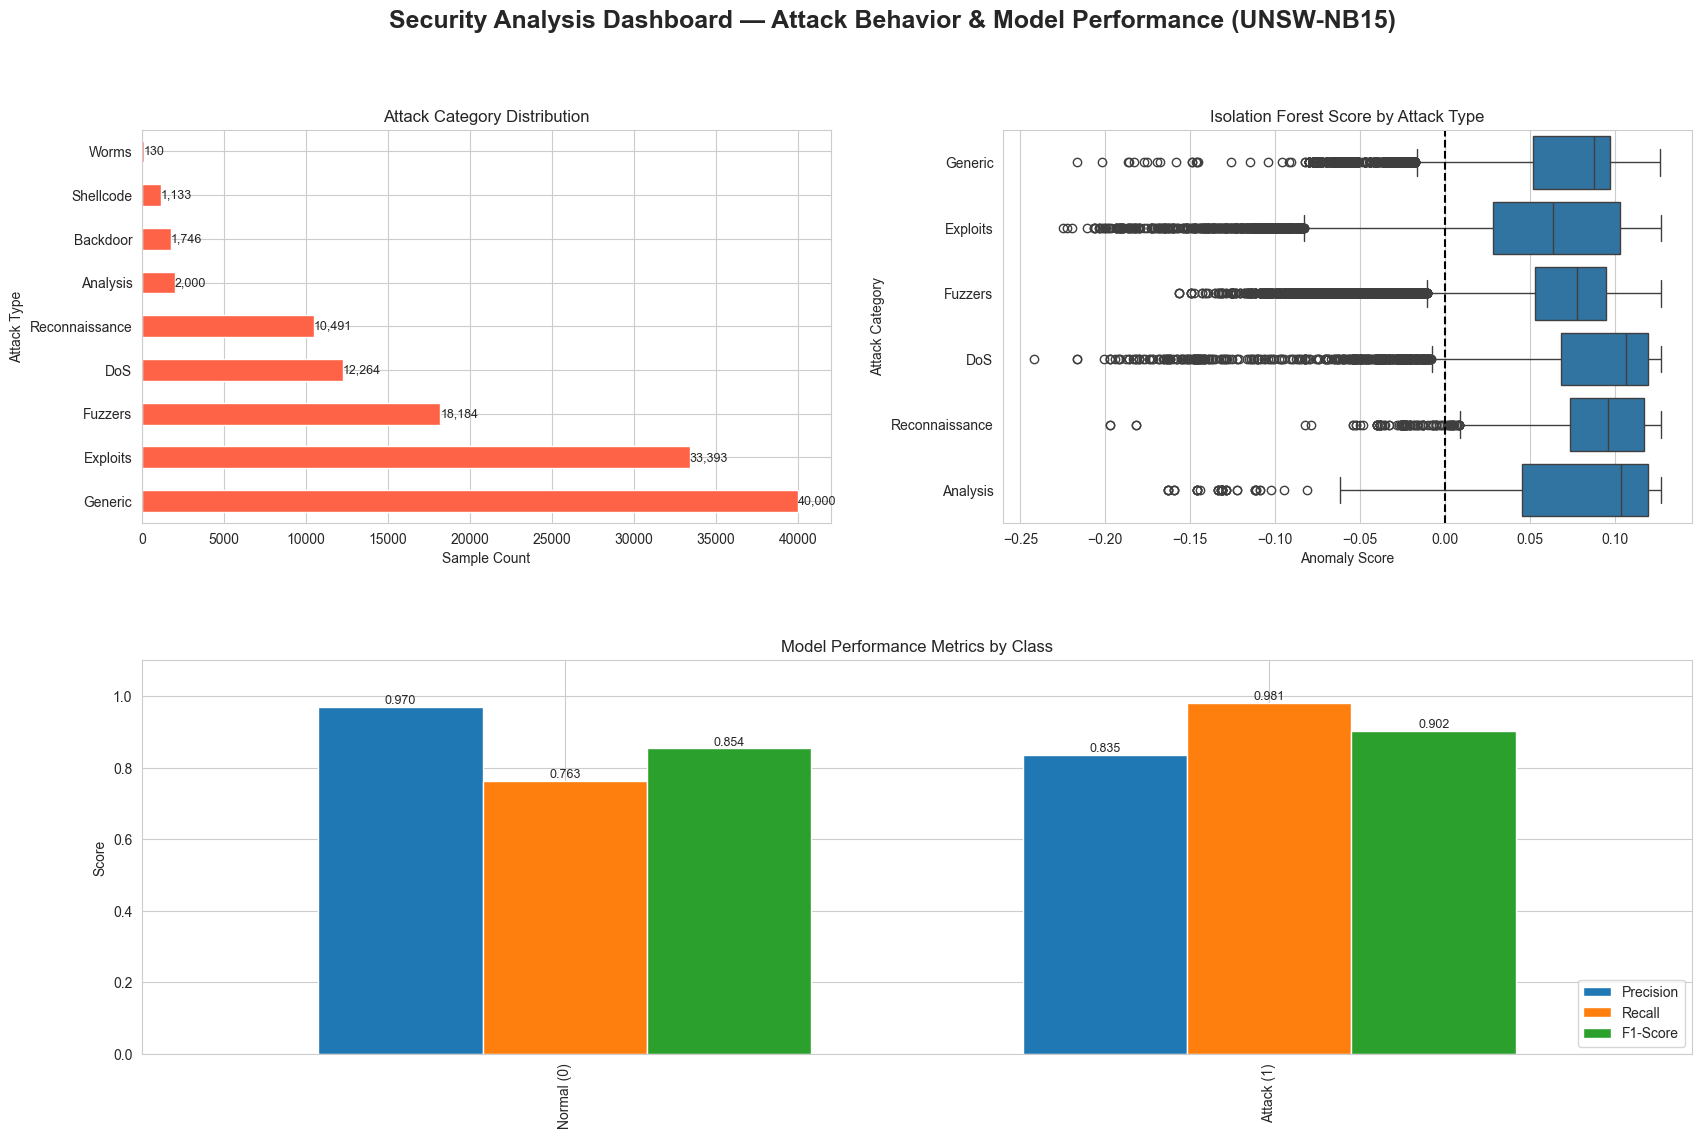

Unified Figure 7 dashboard saved successfully ✔


In [9]:
print("Generating Figure 10: Unified Security Dashboard...")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

sns.set_style("whitegrid")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

fig.suptitle(
    "Figure 10: Security Analysis Dashboard — Attack Behavior & Model Performance\n(UNSW-NB15 | Bipin Shrestha)",
    fontsize=18, fontweight="bold", y=0.98
)

# ─────────────────────────────────────────────
# PANEL 1: ATTACK CATEGORY DISTRIBUTION
# ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

if 'attack_cat' in train_df.columns:
    cat_counts = train_df[train_df['label'] == 1]['attack_cat'].value_counts()

    cat_counts.plot(kind='barh', ax=ax1, color='tomato')

    for i, v in enumerate(cat_counts.values):
        ax1.text(v, i, f"{v:,}", va='center', fontsize=9)

    ax1.set_title("Attack Category Distribution")
    ax1.set_xlabel("Sample Count")
    ax1.set_ylabel("Attack Type")
else:
    ax1.text(0.5, 0.5, "attack_cat column not found",
             ha='center', va='center')
    ax1.set_title("Attack Category Distribution")

# ─────────────────────────────────────────────
# PANEL 2: ANOMALY SCORE BY CATEGORY
# ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

if 'attack_cat' in train_df.columns:

    plot_data = train_df[['attack_cat', 'anomaly_score', 'label']].copy()

    top_cats = (
        plot_data[plot_data['label'] == 1]['attack_cat']
        .value_counts()
        .head(6)
        .index
    )

    subset = plot_data[plot_data['attack_cat'].isin(top_cats)]

    sns.boxplot(
        data=subset,
        x='anomaly_score',
        y='attack_cat',
        order=top_cats,
        ax=ax2
    )

    ax2.axvline(0, color='black', linestyle='--')
    ax2.set_title("Isolation Forest Score by Attack Type")
    ax2.set_xlabel("Anomaly Score")
    ax2.set_ylabel("Attack Category")

else:
    ax2.text(0.5, 0.5, "attack_cat column not found",
             ha='center', va='center')
    ax2.set_title("Isolation Forest Score by Attack Type")

# ─────────────────────────────────────────────
# PANEL 3: PRECISION / RECALL / F1
# ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])

metrics = {
    "Precision": [
        precision_score(y_test, y_pred, pos_label=0),
        precision_score(y_test, y_pred, pos_label=1)
    ],
    "Recall": [
        recall_score(y_test, y_pred, pos_label=0),
        recall_score(y_test, y_pred, pos_label=1)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, pos_label=0),
        f1_score(y_test, y_pred, pos_label=1)
    ]
}

df = pd.DataFrame(metrics, index=["Normal (0)", "Attack (1)"])

df.plot(
    kind='bar',
    ax=ax3,
    width=0.7,
    edgecolor='white'
)

ax3.set_title("Model Performance Metrics by Class")
ax3.set_ylabel("Score")
ax3.set_ylim(0, 1.1)
ax3.legend(loc="lower right")

for p in ax3.patches:
    ax3.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

# ─────────────────────────────────────────────
# FINAL OUTPUT
# ─────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "Figure_10_Unified_Security_Dashboard_Bipin_Shrestha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Unified Figure 7 dashboard saved successfully ✔")

Generating FINAL Figure 9: Security Dashboard...


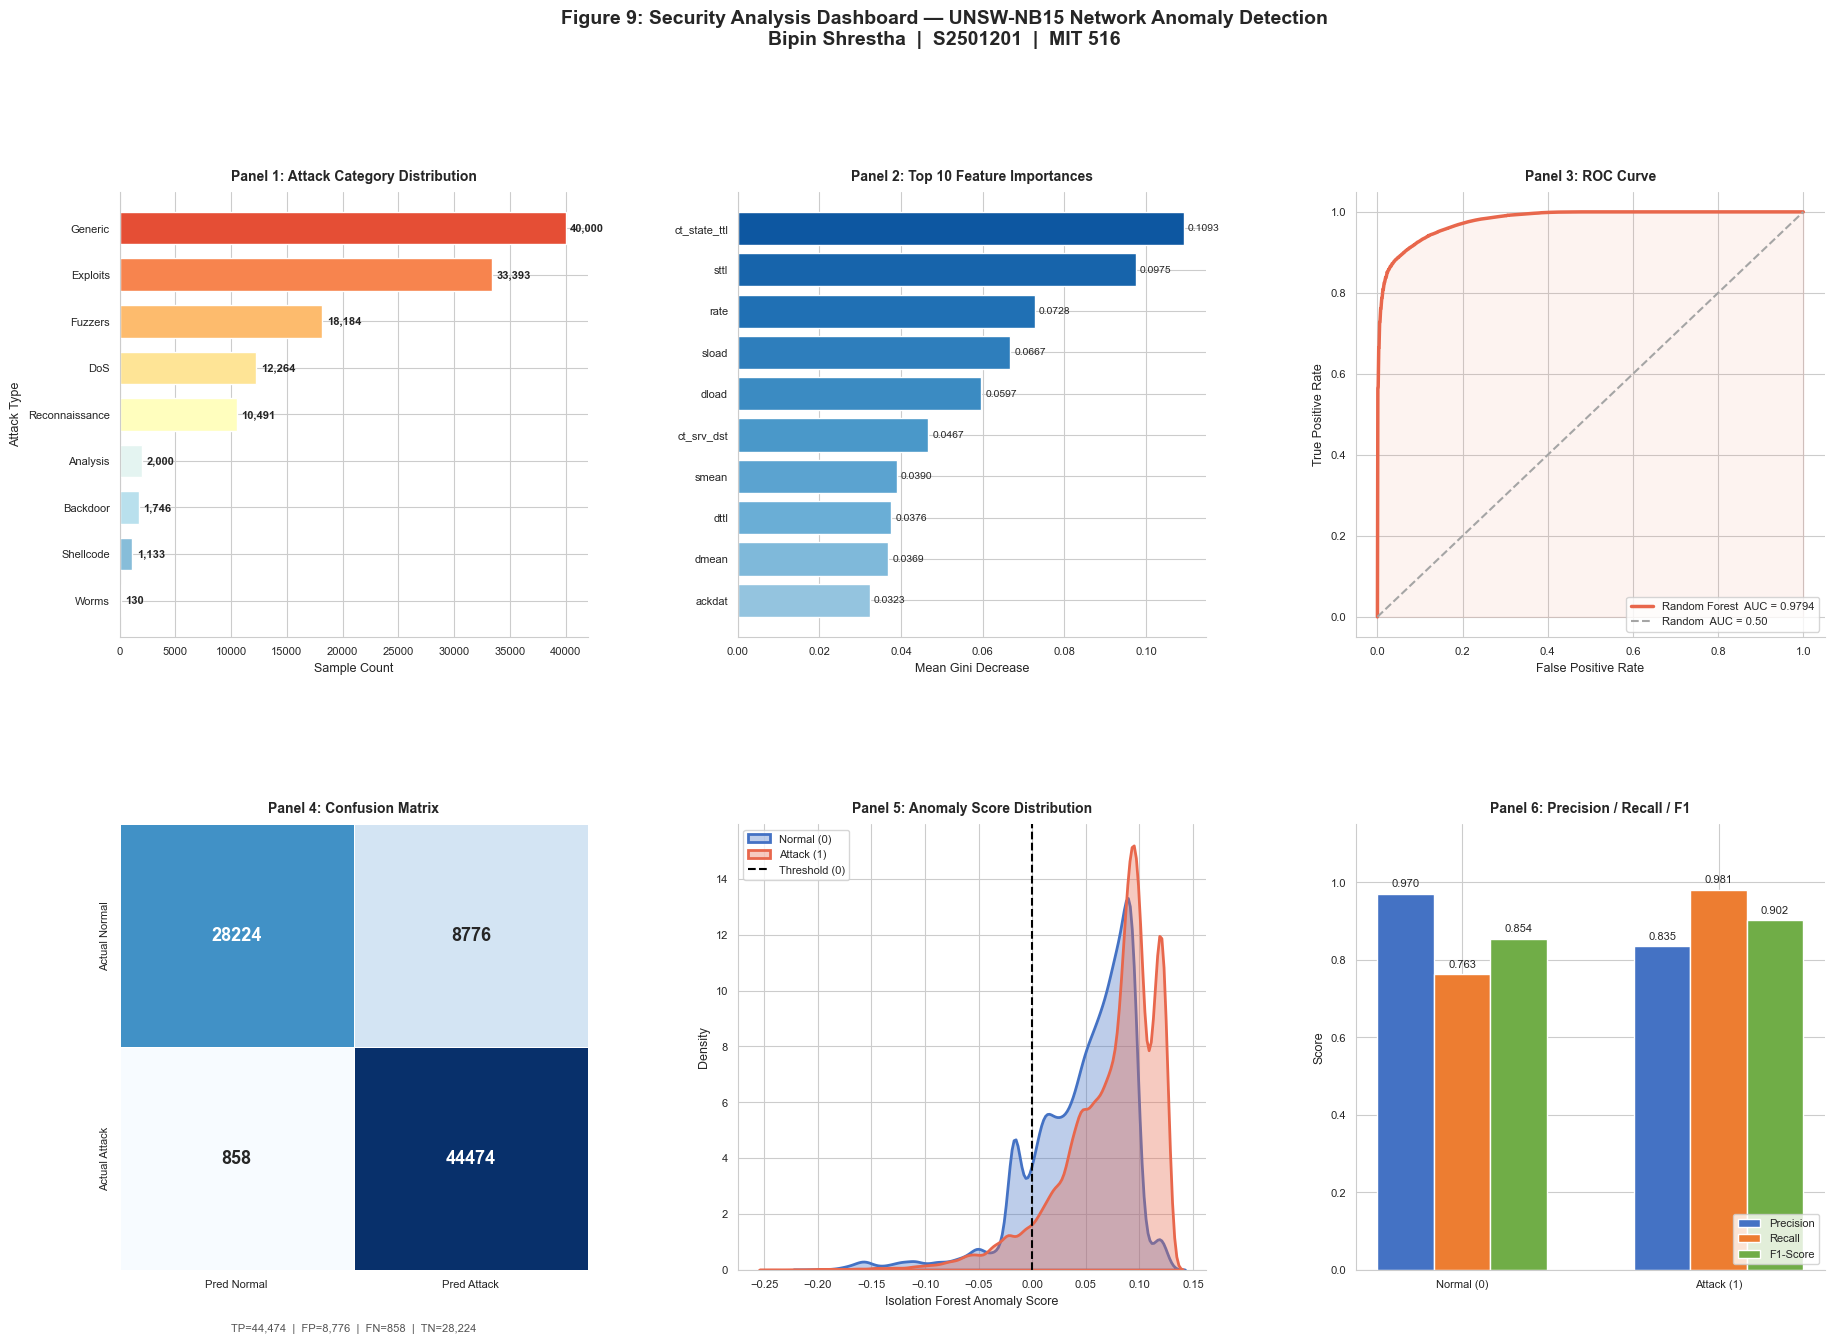

Figure 9 FINAL saved. ✓

--- Results Summary ---
Accuracy : 88.30%
AUC      : 0.9794
TP=44,474  FP=8,776  FN=858  TN=28,224


In [10]:
print('Generating FINAL Figure 9: Security Dashboard...')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score, roc_curve, auc)

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.42, wspace=0.32)

fig.suptitle(
    'Figure 9: Security Analysis Dashboard — UNSW-NB15 Network Anomaly Detection\n'
    'Bipin Shrestha  |  S2501201  |  MIT 516',
    fontsize=14, fontweight='bold', y=1.01
)

BLUE   = '#4472C4'
RED    = '#E8674C'
GREEN  = '#70AD47'
ORANGE = '#ED7D31'
GREY   = '#A5A5A5'

# ── PANEL 1: Attack Category Distribution ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

if 'attack_cat' in train_df.columns:
    cat_counts = (train_df[train_df['label'] == 1]['attack_cat']
                  .value_counts()
                  .sort_values())
    colors_bar = plt.cm.RdYlBu_r(
        np.linspace(0.15, 0.85, len(cat_counts)))
    bars = ax1.barh(cat_counts.index, cat_counts.values,
                    color=colors_bar, edgecolor='white', height=0.7)
    for bar, v in zip(bars, cat_counts.values):
        ax1.text(bar.get_width() + max(cat_counts)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8, fontweight='bold')
    ax1.set_title('Panel 1: Attack Category Distribution',
                  fontsize=10, fontweight='bold', pad=8)
    ax1.set_xlabel('Sample Count', fontsize=9)
    ax1.set_ylabel('Attack Type', fontsize=9)
    ax1.spines[['top', 'right']].set_visible(False)
    ax1.tick_params(labelsize=8)
else:
    ax1.text(0.5, 0.5, 'attack_cat not found',
             ha='center', va='center')
    ax1.set_title('Panel 1: Attack Category Distribution',
                  fontsize=10, fontweight='bold')

# ── PANEL 2: Top 10 Feature Importances ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

imp = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

colors_imp = plt.cm.Blues(np.linspace(0.4, 0.85, 10))
ax2.barh(imp['Feature'][::-1], imp['Importance'][::-1],
         color=colors_imp, edgecolor='white')
for i, (feat, val) in enumerate(
        zip(imp['Feature'][::-1], imp['Importance'][::-1])):
    ax2.text(val + 0.001, i, f'{val:.4f}',
             va='center', fontsize=7.5)
ax2.set_title('Panel 2: Top 10 Feature Importances',
              fontsize=10, fontweight='bold', pad=8)
ax2.set_xlabel('Mean Gini Decrease', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(labelsize=8)

# ── PANEL 3: ROC Curve ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

fpr_vals, tpr_vals, _ = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr_vals, tpr_vals)

ax3.plot(fpr_vals, tpr_vals, color=RED, lw=2.5,
         label=f'Random Forest  AUC = {roc_auc_val:.4f}')
ax3.plot([0, 1], [0, 1], color=GREY, lw=1.5,
         linestyle='--', label='Random  AUC = 0.50')
ax3.fill_between(fpr_vals, tpr_vals, alpha=0.08, color=RED)
ax3.set_xlabel('False Positive Rate', fontsize=9)
ax3.set_ylabel('True Positive Rate', fontsize=9)
ax3.set_title('Panel 3: ROC Curve',
              fontsize=10, fontweight='bold', pad=8)
ax3.legend(loc='lower right', fontsize=8)
ax3.spines[['top', 'right']].set_visible(False)
ax3.tick_params(labelsize=8)

# ── PANEL 4: Confusion Matrix ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])

cm_vals = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm_vals.ravel()

cm_display = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm_display, annot=True, fmt='d',
            cmap='Blues', cbar=False, ax=ax4,
            xticklabels=['Pred Normal', 'Pred Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
ax4.set_title('Panel 4: Confusion Matrix',
              fontsize=10, fontweight='bold', pad=8)
ax4.tick_params(labelsize=8)
ax4.text(0.5, -0.14,
         f'TP={tp:,}  |  FP={fp:,}  |  FN={fn:,}  |  TN={tn:,}',
         ha='center', transform=ax4.transAxes,
         fontsize=8, color='#555555')

# ── PANEL 5: Anomaly Score Distribution ───────────────────────────
ax5 = fig.add_subplot(gs[1, 1])

palette_kde = {0: BLUE, 1: RED}
for label_val, label_name in [(0, 'Normal (0)'), (1, 'Attack (1)')]:
    scores = train_df[train_df['label'] == label_val]['anomaly_score']
    sns.kdeplot(scores, label=label_name,
                color=palette_kde[label_val],
                fill=True, alpha=0.35,
                linewidth=2, ax=ax5)

ax5.axvline(x=0, color='black', linestyle='--',
            linewidth=1.5, label='Threshold (0)')
ax5.set_title('Panel 5: Anomaly Score Distribution',
              fontsize=10, fontweight='bold', pad=8)
ax5.set_xlabel('Isolation Forest Anomaly Score', fontsize=9)
ax5.set_ylabel('Density', fontsize=9)
ax5.legend(fontsize=8, loc='upper left')
ax5.spines[['top', 'right']].set_visible(False)
ax5.tick_params(labelsize=8)

# ── PANEL 6: Precision / Recall / F1 ──────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])

p0 = precision_score(y_test, y_pred, pos_label=0)
r0 = recall_score(y_test,    y_pred, pos_label=0)
f0 = f1_score(y_test,        y_pred, pos_label=0)
p1 = precision_score(y_test, y_pred, pos_label=1)
r1 = recall_score(y_test,    y_pred, pos_label=1)
f1s = f1_score(y_test,       y_pred, pos_label=1)

metric_vals = {
    'Precision': [p0, p1],
    'Recall':    [r0, r1],
    'F1-Score':  [f0, f1s]
}
x6  = np.arange(2)
w6  = 0.22
bar_colors6 = [BLUE, ORANGE, GREEN]

for i, (metric, color) in enumerate(zip(metric_vals, bar_colors6)):
    bars6 = ax6.bar(x6 + i * w6, metric_vals[metric], w6,
                    label=metric, color=color,
                    edgecolor='white')
    for bar in bars6:
        ax6.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.012,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)

ax6.set_xticks(x6 + w6)
ax6.set_xticklabels(['Normal (0)', 'Attack (1)'], fontsize=9)
ax6.set_ylim(0, 1.15)
ax6.set_ylabel('Score', fontsize=9)
ax6.set_title('Panel 6: Precision / Recall / F1',
              fontsize=10, fontweight='bold', pad=8)
ax6.legend(loc='lower right', fontsize=8)
ax6.spines[['top', 'right']].set_visible(False)
ax6.tick_params(labelsize=8)

# ── SAVE ──────────────────────────────────────────────────────────
plt.savefig(
    'Figure_9_Security_Dashboard_FINAL_Bipin_Shrestha.png',
    bbox_inches='tight', dpi=300, facecolor='white'
)
plt.show()
print('Figure 9 FINAL saved. ✓')

# Summary for report
print(f'\n--- Results Summary ---')
print(f'Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'AUC      : {roc_auc_val:.4f}')
print(f'TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')

In [ ]:
# ── Final Results Summary ─────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score

print('=' * 62)
print(' MIT 516 Assessment D — Final Results')
print(' UNSW-NB15 | Bipin Shrestha | S2501201')
print('=' * 62)
print(f'  Accuracy          : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  ROC AUC           : {roc_auc:.4f}')
print(f'  Attack Recall     : {recall_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  Attack Precision  : {precision_score(y_test, y_pred, pos_label=1):.4f}')
print(f'  Normal Recall     : {recall_score(y_test, y_pred, pos_label=0):.4f}')
print(f'  False Negatives   : {fn:,}  (missed attacks)')
print(f'  False Positives   : {fp:,}  (false alarms)')
print('-' * 62)
figures = [
    'Figure_1_Class_Distribution_Bipin_Shrestha.png',
    'Figure_2_Correlation_Heatmap_Bipin_Shrestha.png',
    'Figure_3_Feature_Distribution_Bipin_Shrestha.png',
    'Figure_3_Anomaly_Scores_Bipin_Shrestha.png',
    'Figure_4_Confusion_Matrix_Bipin_Shrestha.png',
    'Figure_5_ROC_Curve_Bipin_Shrestha.png',
    'Figure_5b_Anomaly_by_Category_Bipin_Shrestha.png',
    'Figure_6_Feature_Importance_Bipin_Shrestha.png',
    'Figure_9_Security_Dashboard_6Panel_Bipin_Shrestha.png',
    'Figure_10_Unified_Security_Dashboard_Bipin_Shrestha.png',
]
print('  Figures saved:')
import os
for f in figures:
    status = '✓' if os.path.exists(f) else '✗ not found'
    print(f'    {status}  {f}')
print('=' * 62)